In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\kurum\Downloads\Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()

0

In [6]:
df['Exited'].value_counts()

0    7963
1    2037
Name: Exited, dtype: int64

In [7]:
df['Gender'].value_counts()

Male      5457
Female    4543
Name: Gender, dtype: int64

In [8]:
df = df.drop(df.iloc[:,0:3],axis=1)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True,dtype=int)

In [11]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


# scaling the values


In [12]:
from sklearn.model_selection import train_test_split

x = df.drop("Exited" ,axis=1)
y = df['Exited']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [13]:
x_train.shape

(8000, 11)

In [14]:
x_test.shape

(2000, 11)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

# Creating nural network architecture

In [16]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Creating layers

In [30]:
model = Sequential()
model.add(Dense(11,activation='relu',input_dim=x_train_scaled.shape[1]))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\kurum\anaconda3\envs\tf_gpu_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [51]:
history = model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2) # both training and validation accuracy should increass,,in training accuracy is increaseing and not of validation it is overfitting case

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8716 - loss: 0.3109 - val_accuracy: 0.8675 - val_loss: 0.3233
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8736 - loss: 0.3101 - val_accuracy: 0.8681 - val_loss: 0.3262
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8728 - loss: 0.3094 - val_accuracy: 0.8644 - val_loss: 0.3261
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8722 - loss: 0.3101 - val_accuracy: 0.8644 - val_loss: 0.3255
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8725 - loss: 0.3103 - val_accuracy: 0.8650 - val_loss: 0.3250
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8734 - loss: 0.3109 - val_accuracy: 0.8644 - val_loss: 0.3239
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8742 - loss: 0.3105 - val_accuracy: 0.8669 - val_loss: 0.3238
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8731 - loss: 0.3097 - val_accu

In [46]:
model.layers[0].weights

[<Variable path=sequential_1/dense_2/kernel, shape=(11, 11), dtype=float32, value=[[ 0.2417261  -0.06420048 -0.1536956  -0.05651179  0.25275445 -0.4516194
    0.10978429 -0.43636456  0.13542935  0.00417027 -0.27020618]
  [-0.72905624 -0.40059343  1.097156    0.88335353 -0.58352125 -0.33173922
    0.31095082  0.21671063  0.5086945  -0.2343009   0.3052657 ]
  [-0.24318714 -0.3896966   0.02194714 -0.03165191 -0.12889455  0.14083219
   -0.1129903   0.09962123  0.03089625 -0.12146543  0.38178822]
  [-0.20021391  0.3642257  -0.3040889  -0.09781535 -0.15734959  0.8209601
   -0.05445702  0.02148592 -0.27162215 -0.69428873 -0.92323637]
  [ 0.36953977 -0.23502949 -0.47529468  0.4778696   0.08632746  1.0310948
    1.0995872   0.31487918 -1.0228785  -0.9442278  -0.16950463]
  [ 0.12092956  0.09767045 -0.19994785  0.16286945 -0.27811688 -0.6047361
   -0.03203183  0.12578194 -0.23528345  0.04950273 -0.33233458]
  [-0.14667375 -0.06970418  0.8094564   0.5080644   0.13600586  0.10055015
   -0.21750614

In [48]:
y_pred = np.where(model.predict(x_test_scaled)>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step


In [49]:
from sklearn.metrics import accuracy_score

In [50]:
accuracy_score(y_test,y_pred)

0.8485

In [52]:
history.history

{'accuracy': [0.8715624809265137,
  0.8735937476158142,
  0.8728125095367432,
  0.8721874952316284,
  0.8725000023841858,
  0.8734375238418579,
  0.874218761920929,
  0.8731250166893005,
  0.8726562261581421,
  0.87109375,
  0.8723437786102295,
  0.871874988079071,
  0.8723437786102295,
  0.8728125095367432,
  0.8717187643051147,
  0.8714062571525574,
  0.87109375,
  0.8735937476158142,
  0.87109375,
  0.8745312690734863,
  0.8721874952316284,
  0.8714062571525574,
  0.8729687333106995,
  0.8732812404632568,
  0.8729687333106995,
  0.8737499713897705,
  0.8731250166893005,
  0.8707812428474426,
  0.8720312714576721,
  0.8725000023841858,
  0.8723437786102295,
  0.8729687333106995,
  0.8743749856948853,
  0.8737499713897705,
  0.8729687333106995,
  0.8729687333106995,
  0.875,
  0.8745312690734863,
  0.875,
  0.8734375238418579,
  0.8709375262260437,
  0.8737499713897705,
  0.8725000023841858,
  0.8720312714576721,
  0.8734375238418579,
  0.8726562261581421,
  0.8737499713897705,
  0.87

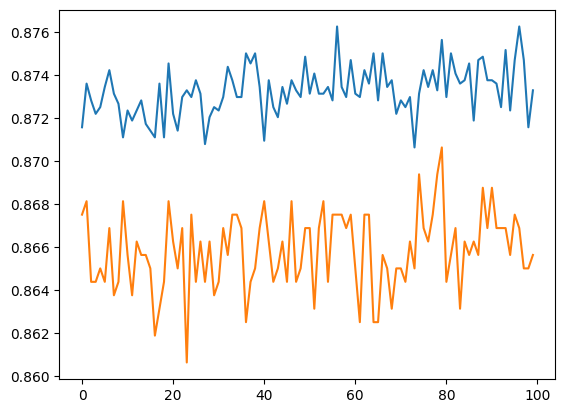

In [58]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])